In [1]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import pylablib

In [2]:
# Create camera sdk (ones!)
from src.pythorcam.camera_cs126 import create_camera_sdk
camerasdk = create_camera_sdk()

Camera 29236 is connected
Camera 29236 is disconnected
0.3663623332977295


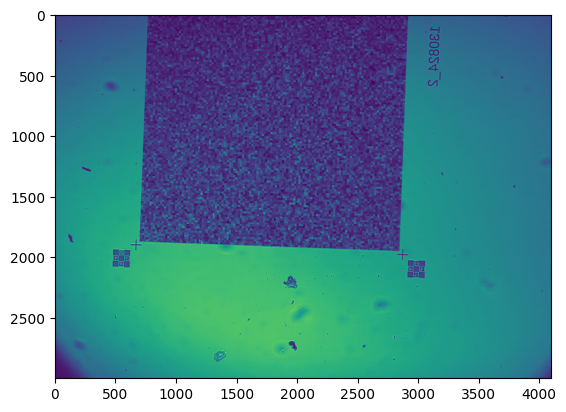

In [8]:
# Camera control
from src.pythorcam.camera_cs126 import Camera_CS126

serial_number = '29236'
Camera = Camera_CS126(camerasdk, serial_number)
Camera.Init_device()
Camera.Set_settings(exposure_time=300000, gain=0, black_level=5, bit_depth=np.uint16, out_bit_depth=np.float32)

Camera.Arm()
time.sleep(0.1)

start = time.time()
image = Camera.Get_image(Num_frames_to_average=1)
end = time.time()

#Continuous_capturing_with_plt(Camera, zoom_value=0.4)

Camera.Disarm()
Camera.Shutdown_device()

print(end - start)

plt.imshow(image)

In [9]:
# Monochromator
from src.monochromator.mono_class import MonochromatorControl

MonochromatorControl.list_available_ports()

['COM3', 'COM4']

In [10]:
monochromator = MonochromatorControl(port='COM4')

Connected to COM4, you can now initialize and start your Monochromator.


In [11]:
monochromator.initialize_arduino()

Your Monochromator is now initialized and on.
Before starting operation please first home the motor.


In [12]:
monochromator.home_motor()

Homing command received.
Photodiode S2: 293
Homed to initial position.
You can now select the grating you wish to operate with.


In [13]:
monochromator.select_grating_mode(mode="VIS Grating")

Grating mode selected. You are now operating with the VIS Grating


In [14]:
monochromator.set_wavelength(wavelength=550)

Moving to wavelength: 550.00
Target wavelength reached. Current wavelength is: 550.00
You can now enter a new wavelength or choose another grating to work with.


In [15]:
monochromator.disconnect()

Disconnected from Arduino.
